In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
for f in os.listdir('allele_differences_withoutcontrol/20240813_allele_only/'):
    if f.endswith('.csv'):
        df= pd.read_csv(f"allele_differences_withoutcontrol/20240813_allele_only/{f}", index_col=0)
        df_index = pd.read_csv('indexing/SNP_haploreg_annotated_20240714.csv',index_col=0).rename(columns={'chr':'chr_number'})
        df_index2= pd.read_csv('indexing/index_20240125_curated.csv',index_col = 0).drop(['RSID','Contributor','Type','nearest_gene'],axis=1)
        df= pd.merge(df,df_index2, left_index=True, right_index=True)
        df= pd.merge(df, df_index, left_index=True, right_index=True)
        # Conditionally assign values
        df['Major'] = np.where(df['REFALT_Flip'], df['a2'], df['a1'])
        df['Minor'] = np.where(df['REFALT_Flip'], df['a1'], df['a2'])
        df.loc[df[(df['EUR']<=0.01) | (df['EUR']>=0.99)].index,"Rare_Common"]="Rare"
        df.loc[df[~((df['EUR']<=0.01) | (df['EUR']>=0.99))].index,"Rare_Common"]="Common"
        df['logFC_converted'] = df.apply(lambda row: -row['logFC'] if row['REFALT_Flip'] else row['logFC'], axis=1)
        df['rsid_gene'] = df["rsid"]+df['Major']+":"+df['Minor']+" ("+df["closest_protein_coding_gene_TSS"]+")"
        df.to_csv('allele_differences_withoutcontrol/20240817_allele_only_for_plotting/'+"annotated_"+f)
        
df_index_new = pd.merge(df_index, df_index2, left_index=True, right_index=True)
df_index_new['Major'] = np.where(df_index_new['REFALT_Flip'], df_index_new['a2'], df_index_new['a1'])
df_index_new['Minor'] = np.where(df_index_new['REFALT_Flip'], df_index_new['a1'], df_index_new['a2'])
df_index_new.loc[df_index_new[(df_index_new['EUR']<=0.01) | (df_index_new['EUR']>=0.99)].index,"Rare_Common"]="Rare"
df_index_new.loc[df_index_new[~((df_index_new['EUR']<=0.01) | (df_index_new['EUR']>=0.99))].index,"Rare_Common"]="Common"
df_index_new['rsid_gene'] = df["rsid"]+df['Major']+":"+df['Minor']+" ("+df["closest_protein_coding_gene_TSS"]+")"
#df_index_new.to_csv('indexing/SNP_haploreg_annotated_index_20240818_curated_annotated.csv')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
def volcano_plot_major_minor(df, title, logFC_threshold, fdr_threshold,ylim,xlim=(-1.2,1.2),save_path=None,label_number = 14):
    # Calculate -log10(FDR)
    df['-log10(fdr)'] = -np.log10(df['fdr'])

    # Determine threshold for significant hits
    fdr_threshold_log10 = -np.log10(fdr_threshold)  # Example threshold for FDR, corresponding to FDR of 0.05

    # Filter out significant hits
    #significant_hits = df[(abs(df['logFC_converted']) > logFC_converted_threshold) & (df['-log10(fdr)'] > fdr_threshold_log10)]
    significant_hits = df.sort_values('fdr',ascending=True).head(label_number)
    # Plotting
    fig, ax = plt.subplots(figsize=(9, 6), dpi=100)

    # All points
    ax.scatter(df['logFC_converted'], df['-log10(fdr)'], color='grey', alpha=0.3, s=4, label='Not significant')  # Reduced dot size and increased transparency

    # Points with logFC_converted > 0 and fdr < 0.05 (blue)
    blue_hits = df[(df['logFC_converted'] > logFC_threshold) & (df['fdr'] < 0.05)]
    ax.scatter(blue_hits['logFC_converted'], -np.log10(blue_hits['fdr']), color='#00AFBB', s=4, label='Major allele > Minor allele, fdr < 0.05', alpha=0.8)

    # Points with logFC_converted < 0 and fdr < 0.05 (red)
    red_hits = df[(df['logFC_converted'] < -logFC_threshold) & (df['fdr'] < 0.05)]
    ax.scatter(red_hits['logFC_converted'], -np.log10(red_hits['fdr']), color='red', s=4, label='Major allele < Minor allele, fdr < 0.05', alpha=0.8)

    # Adding text labels for significant hits
    texts = []
    for _, row in significant_hits.iterrows():
        texts.append(ax.text(row['logFC_converted'], row['-log10(fdr)'], row["RSID_Gene_Contributor"],
                             fontsize=8, ha='center', va='bottom',
                             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', linewidth=0.8, alpha=0.3)))

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black'), linewidth=0.5, alpha=0.8, force_text=(1, 1))

    # Add reference lines for significance thresholds
    ax.axhline(y=fdr_threshold_log10, color='black', linestyle='--', alpha=0.8)
    ax.set_xlim(xlim)

    # Set the visibility of the top and right spines to False
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Labels and title
    ax.set_xlabel('Log fold change', fontsize=14)
    ax.set_ylabel('-Log10 FDR', fontsize=14)
    ax.set_title(title)

    # Move the legend outside of the figure
 #   ax.legend(loc='upper left', bbox_to_anchor=(1, 0.6), frameon=False)
    if ylim:
        plt.ylim(ylim)
    # Adjust the plot layout to make room for the legend
    plt.tight_layout()
    plt.savefig(save_path, format='pdf',dpi=300)
    # Show the plot
    plt.show()
'''
###########################################AD GWAS and AD Genome Project###############################################################
df_annotated = pd.read_csv('allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv',index_col=0)
df_annotated["RSID_Gene_Contributor"]=df_annotated["rsid"]+df_annotated['Major']+":"+df_annotated['Minor']+" ("+df_annotated["closest_protein_coding_gene_TSS"]+")"#+df_annotated["Contributor"]
df_annotated = df_annotated[df_annotated['center']!="MOTIFDISRUPT"]
df = df_annotated[(df_annotated["Contributor"] == "Hide") | (df_annotated["Contributor"] == "Tanzi")]
volcano_plot_major_minor(df,title = 'Allele Differences in Brain Tissues, AD Genome Project Variants',logFC_threshold= 0,fdr_threshold=0.05,ylim=(0,8),xlim=(-1.2,1.2))
df = df_annotated[(df_annotated["Contributor"] == "Pfenning") | (df_annotated["Contributor"] == "Kellis")]
volcano_plot_major_minor(df,title = 'Allele Differences in Brain Tissues, AD GWAS Variants',logFC_threshold= 0,fdr_threshold=0.05,ylim=(0,8),xlim=(-1.2,1.2))
'''


'\n###########################################AD GWAS and AD Genome Project###############################################################\ndf_annotated = pd.read_csv(\'allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv\',index_col=0)\ndf_annotated["RSID_Gene_Contributor"]=df_annotated["rsid"]+df_annotated[\'Major\']+":"+df_annotated[\'Minor\']+" ("+df_annotated["nearest_gene"]+")"#+df_annotated["Contributor"]\ndf_annotated = df_annotated[df_annotated[\'center\']!="MOTIFDISRUPT"]\ndf = df_annotated[(df_annotated["Contributor"] == "Hide") | (df_annotated["Contributor"] == "Tanzi")]\nvolcano_plot_major_minor(df,title = \'Allele Differences in Brain Tissues, AD Genome Project Variants\',logFC_threshold= 0,fdr_threshold=0.05,ylim=(0,8),xlim=(-1.2,1.2))\ndf = df_annotated[(df_annotated["Contributor"] == "Pfenning") | (df_annotated["Contributor"] == "Kellis")]\nvolcano_plot_major_minor(df,title = \'Allele 

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text
import pandas as pd
def volcano_plot_major_minor(
    df, 
    title, 
    logFC_threshold,
    fdr_threshold,
    ylim,
    xlim=(-1.2, 1.2),
    save_path=None,
    label_number = 14,
    fig_size = (10, 5)
):
    # Calculate -log10(FDR)
    df['-log10(fdr)'] = -np.log10(df['fdr'])

    # Determine threshold for significant hits
    fdr_threshold_log10 = -np.log10(fdr_threshold)

    # Select top hits for labeling (by smallest FDR)
    significant_hits = df.sort_values('fdr', ascending=True).head(label_number)

    # Create figure
    fig, ax = plt.subplots(figsize=fig_size, dpi=100)


    # 2) Points with logFC_converted > logFC_threshold and fdr < 0.05 (blue)
    blue_hits = df[
        (df['logFC_converted'] > logFC_threshold) & 
        (df['fdr'] < 0.05)
    ]
    ax.scatter(
        blue_hits['logFC_converted'],
        -np.log10(blue_hits['fdr']),
        color='#00AFBB',
        s=4,
        label='Major allele > Minor allele, top hits ',
        alpha=0.8
    )

    # 3) Points with logFC_converted < -logFC_threshold and fdr < 0.05 (red)
    red_hits = df[
        (df['logFC_converted'] < -logFC_threshold) & 
        (df['fdr'] < 0.05)
    ]
    ax.scatter(
        red_hits['logFC_converted'],
        -np.log10(red_hits['fdr']),
        color='red',
        s=4,
        label='Major allele < Minor allele, top hits',
        alpha=0.8
    )

    # 4) Points with fdr > 0.05 AND abs(logFC) < logFC_threshold (dark green)
    green_hits = df[
        (df['fdr'] <= 0.05) &
        (df['logFC_converted'].abs() < logFC_threshold)
    ]
    ax.scatter(
        green_hits['logFC_converted'],
        green_hits['-log10(fdr)'],
        color='darkgreen',
        s=4,
        label='FDR < 0.05',
        alpha=0.8
    )
    # 1) Plot all points in grey
    ax.scatter(
        df['logFC_converted'],
        df['-log10(fdr)'],
        color='grey',
        alpha=0.3,
        s=4,
        label='Not significant'
    )

    # Add text labels for the top hits
    texts = []
    for _, row in significant_hits.iterrows():
        texts.append(
            ax.text(
                row['logFC_converted'],
                row['-log10(fdr)'],
                row["RSID_Gene_Contributor"],
                fontsize=10, ha='center', va='bottom',
                bbox=dict(
                    boxstyle='round,pad=0.3',
                    facecolor='white',
                    edgecolor='black',
                    linewidth=0.8,
                    alpha=0.3
                )
            )
        )

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle='-', color='black'),
        linewidth=0.5,
        alpha=0.8,
        force_text=(1, 1)
    )

    # Horizontal line at the significance threshold
    ax.axhline(y=fdr_threshold_log10, color='black', linestyle='--', alpha=0.8)

    # X and Y limits
    ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Labels, title, legend
    ax.set_xlabel('Log fold change', fontsize=14)
    ax.set_ylabel('-Log10 FDR', fontsize=14)
    ax.set_title(title)
    ax.legend(frameon=False, loc='best')

    # Tight layout
    plt.tight_layout()

    # Save if a path is given
    if save_path:
        plt.savefig(save_path, format='pdf', dpi=300)

    # Show plot
    plt.show()


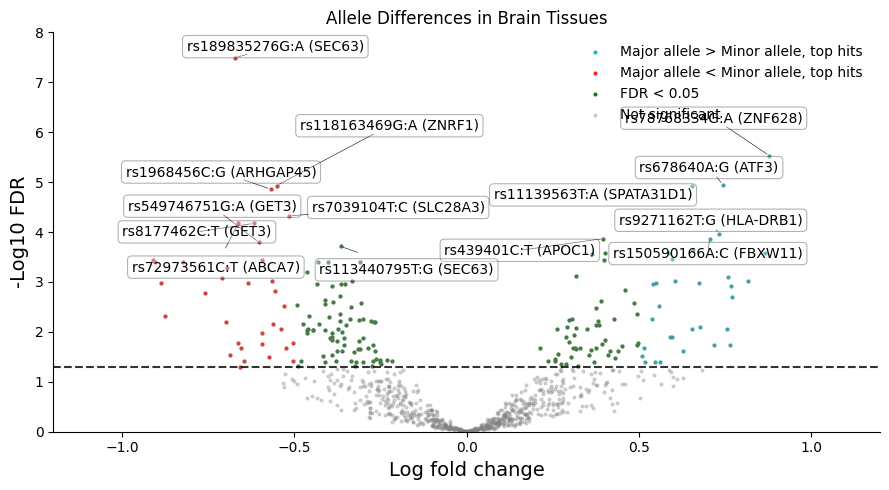

In [24]:
###########################################Rare and Common Variants###############################################################
df_annotated = pd.read_csv('allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv',index_col=0)
df_annotated["RSID_Gene_Contributor"]=df_annotated["rsid"]+df_annotated['Major']+":"+df_annotated['Minor']+" ("+df_annotated["closest_protein_coding_gene_TSS"]+")"#+df_annotated["Contributor"]
df_annotated = df_annotated[df_annotated['center']!="MOTIFDISRUPT"]

volcano_plot_major_minor(df_annotated, title='Allele Differences in Brain Tissues', logFC_threshold=0.5, fdr_threshold=0.05, ylim=(0,8), xlim=(-1.2,1.2),    fig_size = (9, 5), save_path='Allele Differences in Brain Tissues.pdf')


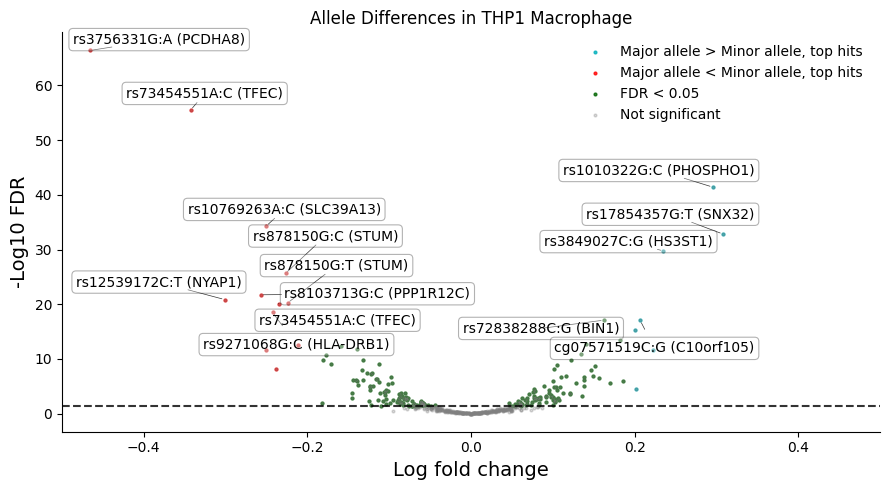

In [28]:
###########################################Rare and Common Variants###############################################################
df_annotated = pd.read_csv('allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv',index_col=0)
df_annotated["RSID_Gene_Contributor"]=df_annotated["rsid"]+df_annotated['Major']+":"+df_annotated['Minor']+" ("+df_annotated["closest_protein_coding_gene_TSS"]+")"#+df_annotated["Contributor"]
df_annotated = df_annotated[df_annotated['center']!="MOTIFDISRUPT"]

volcano_plot_major_minor(df, title='Allele Differences in THP1 Macrophage', logFC_threshold=0.2, fdr_threshold=0.05, ylim=False, xlim=(-0.5,0.5), fig_size = (9, 5), save_path='Allele Differences in THP1 Macrophage.pdf')

/tmp/ipykernel_724262/4046165695.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['-log10(fdr)'] = -np.log10(df['fdr'])


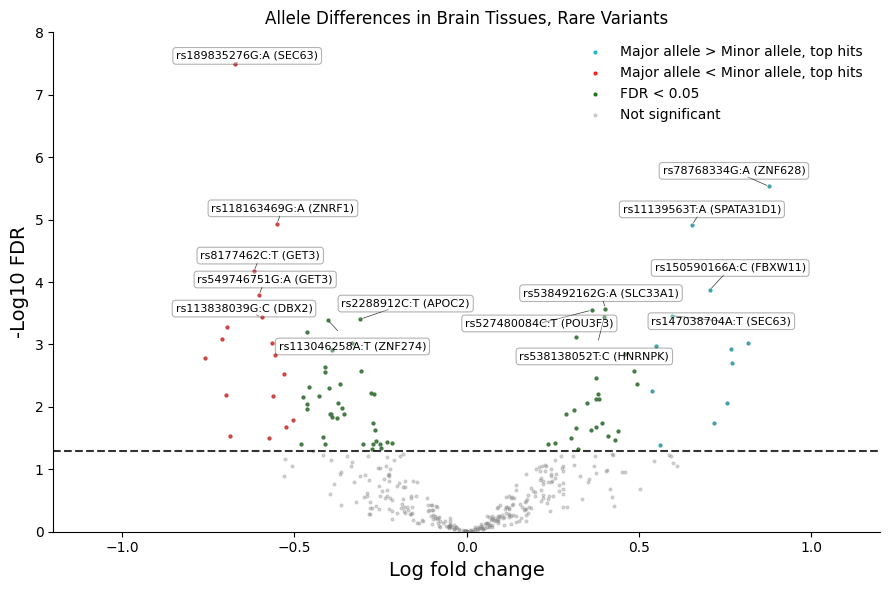

/tmp/ipykernel_724262/4046165695.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['-log10(fdr)'] = -np.log10(df['fdr'])


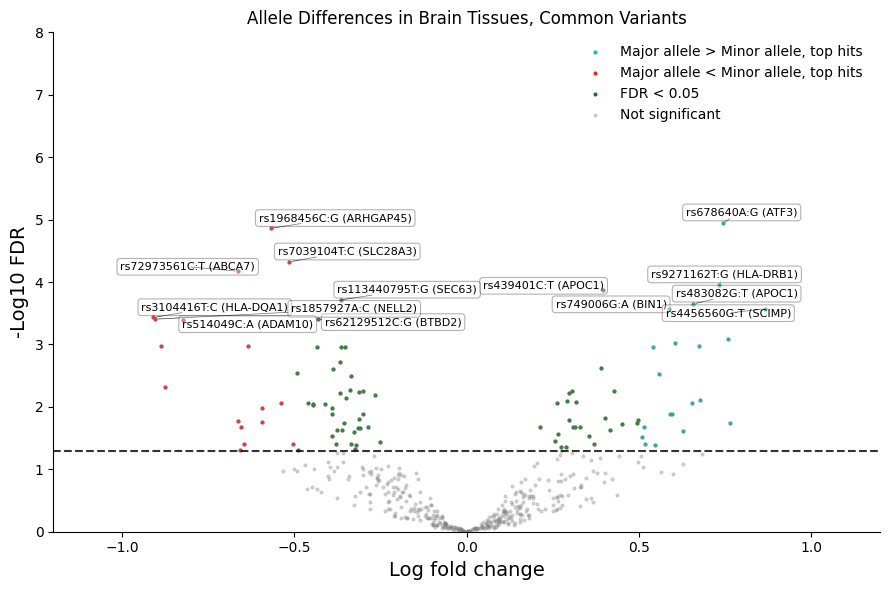

In [6]:
###########################################Rare and Common Variants###############################################################
df_annotated = pd.read_csv('allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv',index_col=0)
df_annotated["RSID_Gene_Contributor"]=df_annotated["rsid"]+df_annotated['Major']+":"+df_annotated['Minor']+" ("+df_annotated["closest_protein_coding_gene_TSS"]+")"#+df_annotated["Contributor"]
df_annotated = df_annotated[df_annotated['center']!="MOTIFDISRUPT"]
df = df_annotated[(df_annotated["Rare_Common"] == "Rare")]
# Plot 3: Rare Variants
df = df_annotated[(df_annotated["Rare_Common"] == "Rare")]
volcano_plot_major_minor(df, title='Allele Differences in Brain Tissues, Rare Variants', logFC_threshold=0.5, fdr_threshold=0.05, ylim=(0,8), xlim=(-1.2,1.2), save_path='Allele Differences in Brain Tissues, Rare Variants.pdf')
# Plot 4: Common Variants
df = df_annotated[(df_annotated["Rare_Common"] == "Common")]
volcano_plot_major_minor(df, title='Allele Differences in Brain Tissues, Common Variants', logFC_threshold=0.5, fdr_threshold=0.05, ylim=(0,8), xlim=(-1.2,1.2), save_path='Allele Differences in Brain Tissues, Common Variants.pdf')

/tmp/ipykernel_3996290/704526316.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['-log10(fdr)'] = -np.log10(df['fdr'])


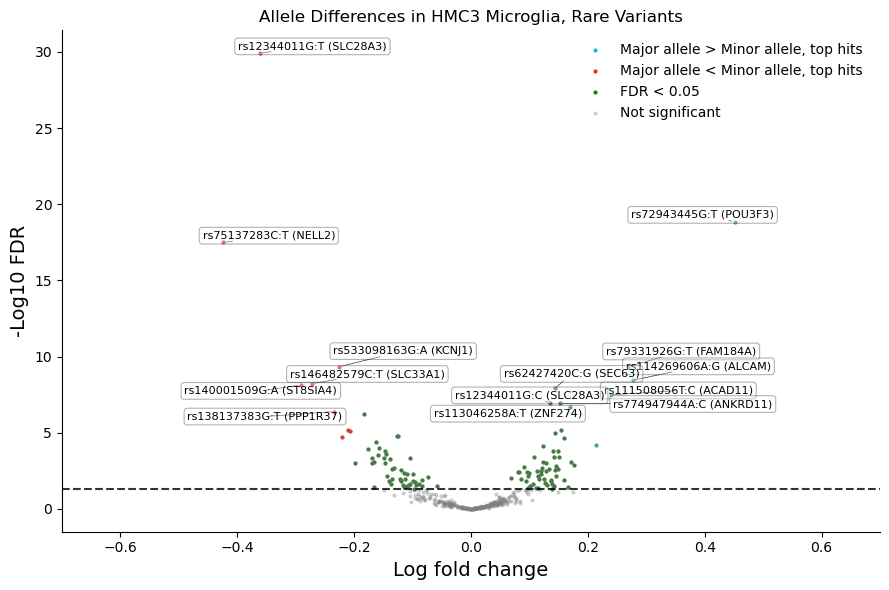

/tmp/ipykernel_3996290/704526316.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['-log10(fdr)'] = -np.log10(df['fdr'])


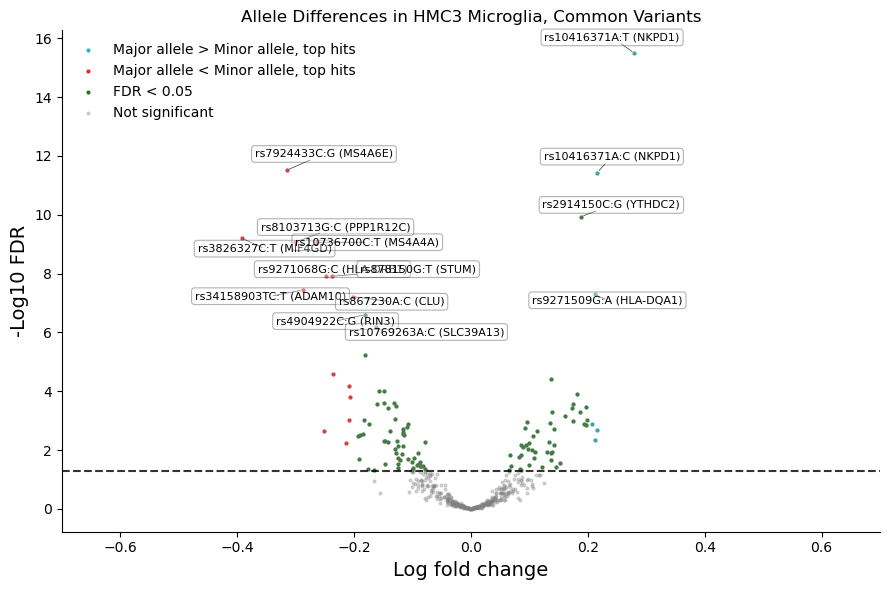

In [19]:

df_annotated = pd.read_csv('allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240812_comparative_HMC3_alleleOnly.csv',index_col=0)
df_annotated["RSID_Gene_Contributor"]=df_annotated["rsid"]+df_annotated['Major']+":"+df_annotated['Minor']+" ("+df_annotated["closest_protein_coding_gene_TSS"]+")"#+df_annotated["Contributor"]
df_annotated = df_annotated[df_annotated['center']!="MOTIFDISRUPT"]
df = df_annotated[(df_annotated["Rare_Common"] == "Rare")]
# Plot 3: Rare Variants
df = df_annotated[(df_annotated["Rare_Common"] == "Rare")]
volcano_plot_major_minor(df, title='Allele Differences in HMC3 Microglia, Rare Variants', logFC_threshold=0.2, fdr_threshold=0.05, ylim=False, xlim=(-0.7,0.7), save_path='Allele Differences in HMC3, Rare Variants.pdf')
# Plot 4: Common Variants
df = df_annotated[(df_annotated["Rare_Common"] == "Common")]
volcano_plot_major_minor(df, title='Allele Differences in HMC3 Microglia, Common Variants', logFC_threshold=0.2, fdr_threshold=0.05, ylim=False, xlim=(-0.7,0.7), save_path='Allele Differences in HMC3, Common Variants.pdf')

/tmp/ipykernel_724262/4046165695.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['-log10(fdr)'] = -np.log10(df['fdr'])


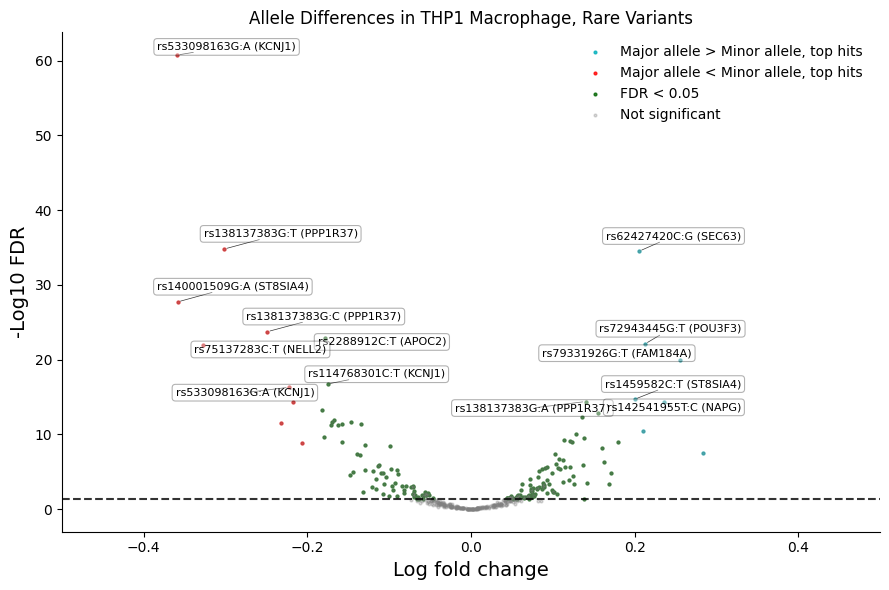

/tmp/ipykernel_724262/4046165695.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['-log10(fdr)'] = -np.log10(df['fdr'])


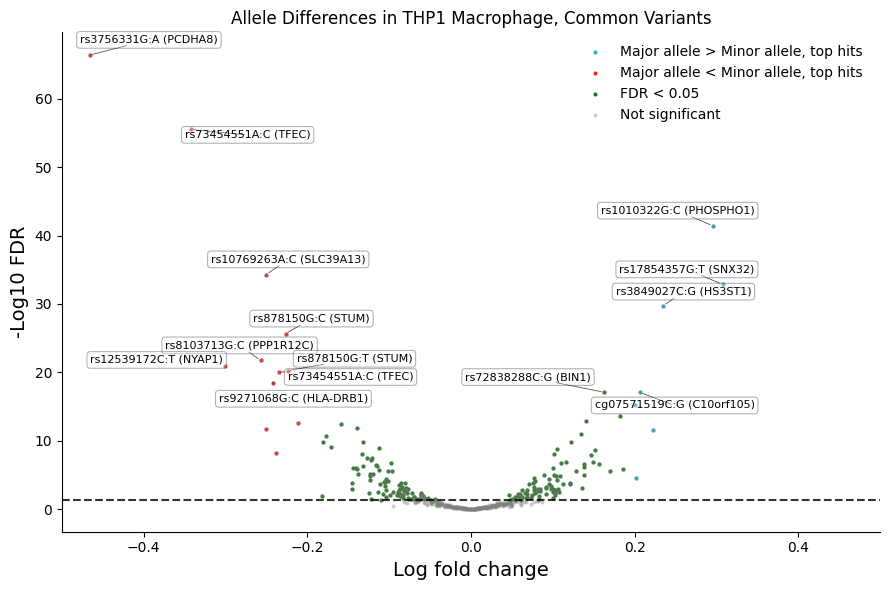

In [7]:
df_annotated = pd.read_csv('allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv',index_col=0)
df_annotated["RSID_Gene_Contributor"]=df_annotated["rsid"]+df_annotated['Major']+":"+df_annotated['Minor']+" ("+df_annotated["closest_protein_coding_gene_TSS"]+")"#+df_annotated["Contributor"]
df_annotated = df_annotated[df_annotated['center']!="MOTIFDISRUPT"]
df = df_annotated[(df_annotated["Rare_Common"] == "Rare")]
# Plot 3: Rare Variants
df = df_annotated[(df_annotated["Rare_Common"] == "Rare")]
volcano_plot_major_minor(df, title='Allele Differences in THP1 Macrophage, Rare Variants', logFC_threshold=0.2, fdr_threshold=0.05, ylim=False, xlim=(-0.5,0.5), save_path='Allele Differences in THP1 Macrophage, Rare Variants.pdf')
# Plot 4: Common Variants
df = df_annotated[(df_annotated["Rare_Common"] == "Common")]
volcano_plot_major_minor(df, title='Allele Differences in THP1 Macrophage, Common Variants', logFC_threshold=0.2, fdr_threshold=0.05, ylim=False, xlim=(-0.5,0.5), save_path='Allele Differences in THP1 Macrophage, Common Variants.pdf')

In [ ]:

df_annotated = pd.read_csv('allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240812_comparative_HMC3_alleleOnly.csv',index_col=0)
df_annotated["RSID_Gene_Contributor"]=df_annotated["rsid"]+df_annotated['Major']+":"+df_annotated['Minor']+" ("+df_annotated["closest_protein_coding_gene_TSS"]+")"#+df_annotated["Contributor"]
df_annotated = df_annotated[df_annotated['center']!="MOTIFDISRUPT"]
df = df_annotated[(df_annotated["Rare_Common"] == "Rare")]
# Plot 3: Rare Variants
df = df_annotated[(df_annotated["Rare_Common"] == "Rare")]
volcano_plot_major_minor(df, title='Allele Differences in HMC3 Microglia, Rare Variants', logFC_threshold=0, fdr_threshold=0.05, ylim=False, xlim=(-0.7,0.7), save_path='Allele Differences in HMC3, Rare Variants.pdf')
# Plot 4: Common Variants
df = df_annotated[(df_annotated["Rare_Common"] == "Common")]
volcano_plot_major_minor(df, title='Allele Differences in HMC3 Microglia, Common Variants', logFC_threshold=0, fdr_threshold=0.05, ylim=False, xlim=(-0.7,0.7), save_path='Allele Differences in HMC3, Common Variants.pdf')




df_annotated = pd.read_csv('allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240719_comparative_HEK293T_alleleOnly.csv',index_col=0)
df_annotated["RSID_Gene_Contributor"]=df_annotated["rsid"]+df_annotated['Major']+":"+df_annotated['Minor']+" ("+df_annotated["closest_protein_coding_gene_TSS"]+")"#+df_annotated["Contributor"]
df_annotated = df_annotated[df_annotated['center']!="MOTIFDISRUPT"]
df = df_annotated[(df_annotated["Rare_Common"] == "Rare")]
# Plot 3: Rare Variants
df = df_annotated[(df_annotated["Rare_Common"] == "Rare")]
volcano_plot_major_minor(df, title='Allele Differences in HEK293T, Rare Variants', logFC_threshold=0, fdr_threshold=0.05, ylim=False, xlim=(-0.7,0.7), save_path='Allele Differences in HEK293T, Rare Variants.pdf')
# Plot 4: Common Variants
df = df_annotated[(df_annotated["Rare_Common"] == "Common")]
volcano_plot_major_minor(df, title='Allele Differences in HEK293T, Common Variants', logFC_threshold=0, fdr_threshold=0.05, ylim=False, xlim=(-0.7,0.7), save_path='Allele Differences in HEK293T, Common Variants.pdf')


df_annotated = pd.read_csv('allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240719_comparative_THP1Monocyte_alleleOnly.csv',index_col=0)
df_annotated["RSID_Gene_Contributor"]=df_annotated["rsid"]+df_annotated['Major']+":"+df_annotated['Minor']+" ("+df_annotated["closest_protein_coding_gene_TSS"]+")"#+df_annotated["Contributor"]
df_annotated = df_annotated[df_annotated['center']!="MOTIFDISRUPT"]
df = df_annotated[(df_annotated["Rare_Common"] == "Rare")]
# Plot 3: Rare Variants
df = df_annotated[(df_annotated["Rare_Common"] == "Rare")]
volcano_plot_major_minor(df, title='Allele Differences in THP1 Monocyte, Rare Variants', logFC_threshold=0, fdr_threshold=0.05, ylim=False, xlim=(-0.7,0.7), save_path='Allele Differences in THP1 Monocyte, Rare Variants.pdf',label_number=1)
# Plot 4: Common Variants
df = df_annotated[(df_annotated["Rare_Common"] == "Common")]
volcano_plot_major_minor(df, title='Allele Differences in THP1 Monocyte, Common Variants', logFC_threshold=0, fdr_threshold=0.05, ylim=False, xlim=(-0.7,0.7), save_path='Allele Differences in THP1 Monocyte, Common Variants.pdf',label_number=2)


df_annotated = pd.read_csv('allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240814_comparative_GutR1R2merged20240404_alleleOnly.csv',index_col=0)
df_annotated["RSID_Gene_Contributor"]=df_annotated["rsid"]+df_annotated['Major']+":"+df_annotated['Minor']+" ("+df_annotated["closest_protein_coding_gene_TSS"]+")"#+df_annotated["Contributor"]
df_annotated = df_annotated[df_annotated['center']!="MOTIFDISRUPT"]
df = df_annotated[(df_annotated["Rare_Common"] == "Rare")]
# Plot 3: Rare Variants
df = df_annotated[(df_annotated["Rare_Common"] == "Rare")]
volcano_plot_major_minor(df, title='Allele Differences in Mouse Gut, Rare Variants', logFC_threshold=0, fdr_threshold=0.05, ylim=False, xlim=(-0.7,0.7), save_path='Allele Differences in Mouse Gut, Rare Variants.pdf',label_number=10)
# Plot 4: Common Variants
df = df_annotated[(df_annotated["Rare_Common"] == "Common")]
volcano_plot_major_minor(df, title='Allele Differences in Mouse Gut, Common Variants', logFC_threshold=0, fdr_threshold=0.05, ylim=False, xlim=(-0.7,0.7), save_path='Allele Differences in Mouse Gut, Common Variants.pdf',label_number=10)

